In [6]:
import pandas as pd
import numpy as np

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
# Retain the samples aged 18 or above

nhanes_clean = pd.read_csv("/Users/sherrywang/Desktop/Projects/Dataset/nhanes_clean.csv")
nhanes_clean_adult = nhanes_clean[nhanes_clean['age'] >= 18].copy()
nhanes_clean_adult.to_csv("nhanes_clean_adult.csv")
nhanes_clean_adult.to_pickle("nhanes_clean_adult.pkl")
print(nhanes_clean_adult.shape)

(8153, 21)


In [7]:
#Socio-economic → Insurance type

# Numeric data discretization

# Income poverty ratio discretization
nhanes_clean_adult['income_poverty_ratio_bin'] = pd.cut(
    nhanes_clean_adult['income_poverty_ratio'],
    bins = [0, 1, 2, 4, np.inf],
    labels = ['<=1 (Below poverty line)', '1-2', '2-4', '>4']
)

# Age discretization
nhanes_clean_adult['age_bin'] = pd.cut(
    nhanes_clean_adult['age'],
    bins= [18,30,45,60,80],
    labels= ['18-30', '31-45', '46-60', '61-80'],
    include_lowest=True
)
    
# Select categorical Socio-economic features
soci_cols = [
    'age_bin',
    'gender',
    'race',
    'education',
    'income_poverty_ratio_bin',
    'insurance_type'
]
nhanes_fp = nhanes_clean_adult[soci_cols].dropna().astype(str)

# Convert the dataframe to transaction format
transactions = (
    nhanes_fp
    .apply(lambda r: [f"{c}={r[c]}" for c in nhanes_fp.columns if pd.notna(r[c])], axis=1)
    .tolist()
)

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
nhanes_tf = pd.DataFrame(te_ary, columns = te.columns_)
nhanes_tf

,age_bin=18-30,age_bin=31-45,age_bin=46-60,age_bin=61-80,education=9-11th grade,education=<9th grade,education=College graduate or above,education=High school/GED,education=Some college/AA,education=Unknown,...,insurance_type=Private only,insurance_type=Public only,insurance_type=Uninsured,insurance_type=Unknown,race=Mexican American,race=Non-Hispanic Asian,race=Non-Hispanic Black,race=Non-Hispanic White,race=Other Hispanic,race=Other Race / Multi
0,False,True,False,False,False,False,True,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1,False,False,False,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,True,False,False,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
3,False,True,False,False,True,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,False
4,False,False,False,True,False,False,False,True,False,False,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8148,False,False,False,True,False,True,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False
8149,False,False,True,False,False,False,True,False,False,False,...,False,True,False,False,False,False,True,False,False,False
8150,False,False,True,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
8151,False,True,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False


In [8]:
# Run Apriori algorithm
freq_items = apriori(nhanes_tf, min_support = 0.05, use_colnames = True, max_len = 4)
freq_items.sort_values('support',ascending = False).head()
freq_items[freq_items['itemsets'].apply(lambda x: len(x) > 1)].sort_values('support', ascending=False).head(10)

,support,itemsets
92,0.320005,"(gender=Female, race=Non-Hispanic White)"
59,0.272906,"(race=Non-Hispanic White, age_bin=61-80)"
102,0.256961,"(race=Non-Hispanic White, gender=Male)"
108,0.232920,"(race=Non-Hispanic White, income_poverty_ratio..."
116,0.232430,"(race=Non-Hispanic White, insurance_type=Priva..."
67,0.224580,"(education=College graduate or above, race=Non..."
51,0.222495,"(gender=Female, age_bin=61-80)"
85,0.221391,"(gender=Female, income_poverty_ratio_bin=2-4)"
90,0.220164,"(gender=Female, insurance_type=Public only)"
114,0.207163,"(race=Non-Hispanic White, income_poverty_ratio..."


In [9]:
# Generate Association rule
rules = association_rules(freq_items, metric = 'lift', min_threshold = 1.0)

# KULC
rules['kulc'] = 0.5 * (
    rules['support'] / rules['antecedent support'] +
    rules['support'] / rules['consequent support']
)

# Imbalance Ratio (IR)
rules['ir'] = (
    (rules['antecedent support'] - rules['consequent support']).abs()
    / (rules['antecedent support'] + rules['consequent support'] - rules['support'])
)

# Filter insurance type as the consequent
rules_insurance = rules[rules['consequents'].astype(str).str.contains('insurance_type')]
rules_insurance = rules_insurance.sort_values('lift', ascending=False)

pd.set_option('display.max_colwidth', None)
rules_insurance[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift',
     'kulc', 'ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
587,"(gender=Female, race=Non-Hispanic White, age_bin=61-80)",(insurance_type=Both),0.063903,0.423922,2.695971,0.415159,0.026633
593,"(race=Non-Hispanic White, age_bin=61-80)","(insurance_type=Both, gender=Female)",0.063903,0.234157,2.629593,0.475894,0.616872
316,"(race=Non-Hispanic White, age_bin=61-80)",(insurance_type=Both),0.110879,0.406292,2.583853,0.555720,0.362274
194,"(education=College graduate or above, age_bin=61-80)",(insurance_type=Both),0.052005,0.401135,2.551058,0.365934,0.117493
138,"(income_poverty_ratio_bin=>4, age_bin=31-45)",(insurance_type=Private only),0.052864,0.874239,2.440984,0.510921,0.813883
165,"(income_poverty_ratio_bin=>4, age_bin=46-60)",(insurance_type=Private only),0.059119,0.866906,2.420510,0.515987,0.789579
654,"(gender=Female, income_poverty_ratio_bin=>4)","(education=College graduate or above, insurance_type=Private only)",0.059978,0.418664,2.393668,0.380791,0.122565
726,(income_poverty_ratio_bin=>4),"(education=College graduate or above, race=Non-Hispanic White, insurance_type=Private only)",0.080216,0.286842,2.374237,0.475401,0.495979
592,"(gender=Female, age_bin=61-80)","(insurance_type=Both, race=Non-Hispanic White)",0.063903,0.287211,2.358135,0.405942,0.359143
114,"(education=College graduate or above, age_bin=31-45)",(insurance_type=Private only),0.068318,0.816716,2.280370,0.503734,0.734975


In [10]:
# Filter rules meet the criteria: support > 0.05, confidence > 0.4 and lift > 1.6
rules_insurance = rules[
    (rules['consequents'].astype(str).str.contains('insurance_type')) &
    (rules['support'] > 0.05) &
    ((rules['confidence'] > 0.4) & (rules['lift'] > 1.6)) &
     (rules['consequents'].apply(lambda s: all('insurance_type' in x for x in s)))
].sort_values('lift', ascending=False)

rules_insurance[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift',
     'kulc', 'ir']
].head(15)

,antecedents,consequents,support,confidence,lift,kulc,ir
587,"(gender=Female, race=Non-Hispanic White, age_bin=61-80)",(insurance_type=Both),0.063903,0.423922,2.695971,0.415159,0.026633
316,"(race=Non-Hispanic White, age_bin=61-80)",(insurance_type=Both),0.110879,0.406292,2.583853,0.555720,0.362274
194,"(education=College graduate or above, age_bin=61-80)",(insurance_type=Both),0.052005,0.401135,2.551058,0.365934,0.117493
138,"(income_poverty_ratio_bin=>4, age_bin=31-45)",(insurance_type=Private only),0.052864,0.874239,2.440984,0.510921,0.813883
165,"(income_poverty_ratio_bin=>4, age_bin=46-60)",(insurance_type=Private only),0.059119,0.866906,2.420510,0.515987,0.789579
114,"(education=College graduate or above, age_bin=31-45)",(insurance_type=Private only),0.068318,0.816716,2.280370,0.503734,0.734975
149,"(education=College graduate or above, age_bin=46-60)",(insurance_type=Private only),0.053968,0.791367,2.209594,0.471026,0.778656
144,"(race=Non-Hispanic White, age_bin=31-45)",(insurance_type=Private only),0.069668,0.664327,1.854884,0.429424,0.643904
650,"(gender=Female, education=College graduate or above, income_poverty_ratio_bin=>4)",(insurance_type=Private only),0.059978,0.655496,1.830226,0.411481,0.684293
177,"(race=Non-Hispanic White, age_bin=46-60)",(insurance_type=Private only),0.077885,0.647299,1.807338,0.432382,0.593693


In [11]:
# Narrow the antecedents only within education and income
def antecedent_only_has_edu_income(ant):

    ant_str = str(ant)

    unwanted = ['race', 'gender', 'age_bin']
    return (('education' in ant_str) or ('income' in ant_str)) and not any(u in ant_str for u in unwanted)

rules_filtered_strict = rules_insurance[
    rules_insurance['antecedents'].apply(antecedent_only_has_edu_income)
]
rules_filtered_strict[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'kulc', 'ir']]


,antecedents,consequents,support,confidence,lift,kulc,ir
366,"(education=College graduate or above, income_poverty_ratio_bin=>4)",(insurance_type=Private only),0.109776,0.633853,1.769795,0.470180,0.438755
98,(income_poverty_ratio_bin=<=1 (Below poverty line)),(insurance_type=Public only),0.089415,0.641725,1.675845,0.437615,0.562766
102,(income_poverty_ratio_bin=>4),(insurance_type=Private only),0.166564,0.595614,1.663028,0.530341,0.166580


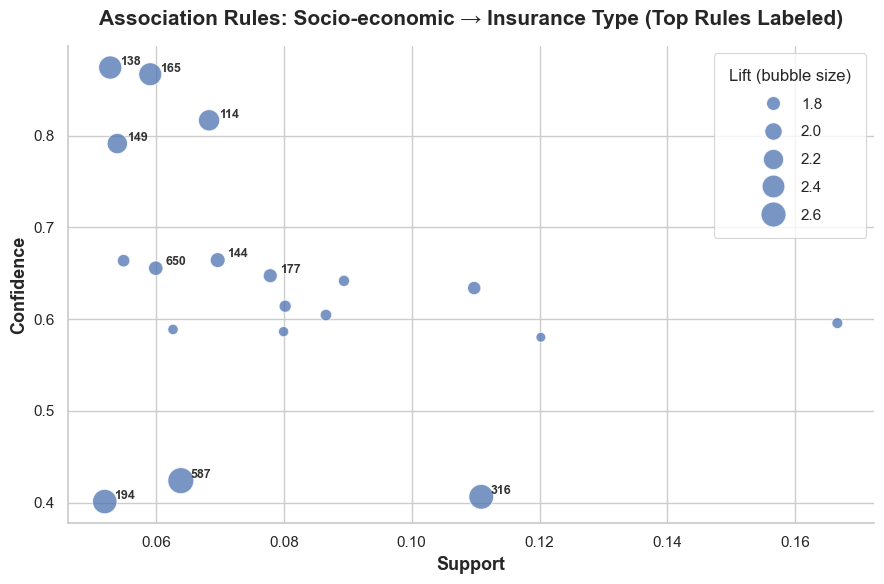

,antecedents,consequents,support,confidence,lift
587,"(gender=Female, race=Non-Hispanic White, age_bin=61-80)",(insurance_type=Both),0.063903,0.423922,2.695971
316,"(race=Non-Hispanic White, age_bin=61-80)",(insurance_type=Both),0.110879,0.406292,2.583853
194,"(education=College graduate or above, age_bin=61-80)",(insurance_type=Both),0.052005,0.401135,2.551058
138,"(income_poverty_ratio_bin=>4, age_bin=31-45)",(insurance_type=Private only),0.052864,0.874239,2.440984
165,"(income_poverty_ratio_bin=>4, age_bin=46-60)",(insurance_type=Private only),0.059119,0.866906,2.420510
114,"(education=College graduate or above, age_bin=31-45)",(insurance_type=Private only),0.068318,0.816716,2.280370
149,"(education=College graduate or above, age_bin=46-60)",(insurance_type=Private only),0.053968,0.791367,2.209594
144,"(race=Non-Hispanic White, age_bin=31-45)",(insurance_type=Private only),0.069668,0.664327,1.854884
650,"(gender=Female, education=College graduate or above, income_poverty_ratio_bin=>4)",(insurance_type=Private only),0.059978,0.655496,1.830226
177,"(race=Non-Hispanic White, age_bin=46-60)",(insurance_type=Private only),0.077885,0.647299,1.807338


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

top_rules = rules_insurance.nlargest(10, 'lift')

plt.figure(figsize=(9, 6))

ax = sns.scatterplot(
    data=rules_insurance,
    x='support',
    y='confidence',
    color='#4C72B0',      
    size='lift',
    sizes=(50, 350),
    alpha=0.75,           
    edgecolor='white',   
    linewidth=0.7
)

for idx, row in top_rules.iterrows():
    ax.text(
        row['support'] + 0.0015,
        row['confidence'] + 0.003,
        str(idx),
        fontsize=9,
        weight='bold',
        color='#333333'
    )

ax.set_title(
    "Association Rules: Socio-economic → Insurance Type (Top Rules Labeled)",
    fontsize=15,
    pad=15,
    fontweight='bold'
)
ax.set_xlabel("Support", fontsize=13, fontweight='bold')
ax.set_ylabel("Confidence", fontsize=13, fontweight='bold')

ax.tick_params(axis='both', labelsize=11)

legend = ax.legend(
    title="Lift (bubble size)",
    title_fontsize=12,
    fontsize=11,
    frameon=True,
    borderpad=1,
    labelspacing=0.9,
    loc='upper right'
)
legend.get_frame().set_linewidth(0.8)
legend.get_frame().set_edgecolor('#CCCCCC')

sns.despine()
plt.tight_layout()
plt.show()

top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

In [13]:
#Lifestyle + Physiological + Insurance → Diabetes risk

# Numeric data discretization

# A1C discretization
nhanes_clean_adult['a1c_bin'] = pd.cut(
    nhanes_clean_adult['a1c'],        
    bins=[0, 5.7, 6.5, np.inf],
    labels=['Normal_A1C', 'Prediabetes_A1C', 'HighA1C_DiabetesRange']
)

# BMI discretization
nhanes_clean_adult['bmi_bin'] = pd.cut(
    nhanes_clean_adult['bmi'],       
    bins=[0, 25, 30, np.inf],
    labels=['Normal', 'Overweight', 'Obesity']
)

# Sleep (hours) discretization
nhanes_clean_adult['sleep_bin'] = pd.cut(
    nhanes_clean_adult['sleep_hours'],   
    bins=[0, 6, 8, np.inf],
    labels=['Short (<6h)', 'Normal (6-8h)', 'Long (>8h)']
)

# Select categorical Lifestyle + Physiological + Insurance features
lifestyle_physio_insurance_features = [
    'a1c_bin',
    'bmi_bin',
    'sleep_bin',
    'smoking_current',
    'insurance_type',
    'diabetes_self_report'
]

nhanes_health_fp = nhanes_clean_adult[lifestyle_physio_insurance_features].dropna().astype(str)

# Convert the dataframe to transaction format
transactions = (
    nhanes_health_fp
    .apply(
        lambda r: [
            f"{c}={r[c]}" 
            for c in nhanes_health_fp.columns 
            if pd.notna(r[c])
        ],
        axis=1
    )
    .tolist()
)


te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
nhanes_health_tf = pd.DataFrame(te_ary, columns = te.columns_)
nhanes_health_tf

# Run Apriori algorithm
freq_items = apriori(nhanes_health_tf, min_support = 0.05, use_colnames = True, max_len = 4)
freq_items.sort_values('support',ascending = False).head()
freq_items[freq_items['itemsets'].apply(lambda x: len(x) > 1)].sort_values('support', ascending=False).head(10)

,support,itemsets
22,0.707838,"(a1c_bin=Normal_A1C, diabetes_self_report=No)"
73,0.516988,"(smoking_current=No, diabetes_self_report=No)"
30,0.476880,"(smoking_current=No, a1c_bin=Normal_A1C)"
130,0.448547,"(smoking_current=No, a1c_bin=Normal_A1C, diabetes_self_report=No)"
71,0.439715,"(sleep_bin=Normal (6-8h), diabetes_self_report=No)"
28,0.401079,"(a1c_bin=Normal_A1C, sleep_bin=Normal (6-8h))"
56,0.376916,"(bmi_bin=Overweight, diabetes_self_report=No)"
128,0.374463,"(sleep_bin=Normal (6-8h), a1c_bin=Normal_A1C, diabetes_self_report=No)"
21,0.371888,"(bmi_bin=Overweight, a1c_bin=Normal_A1C)"
114,0.335950,"(bmi_bin=Overweight, a1c_bin=Normal_A1C, diabetes_self_report=No)"


In [14]:
# Generate Association rule
rules = association_rules(freq_items, metric = 'lift', min_threshold = 1.0)

# KULC
rules['kulc'] = 0.5 * (
    rules['support'] / rules['antecedent support'] +
    rules['support'] / rules['consequent support']
)

# Imbalance Ratio (IR)
rules['ir'] = (
    (rules['antecedent support'] - rules['consequent support']).abs()
    / (rules['antecedent support'] + rules['consequent support'] - rules['support'])
)

# Filter diabete risk as the consequent
rules_diabetes = rules[
    rules['consequents'].astype(str).str.contains('diabetes_self_report')
].copy()
rules_diabetes = rules_diabetes.sort_values('lift', ascending=False)

pd.set_option('display.max_colwidth', None)
rules_diabetes[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift',
     'kulc', 'ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
3,(a1c_bin=HighA1C_DiabetesRange),(diabetes_self_report=Yes),0.066601,0.815315,6.195029,0.660687,0.340301
34,(bmi_bin=Obesity),(diabetes_self_report=Yes),0.065129,0.196521,1.493231,0.345698,0.502158
254,(bmi_bin=Obesity),"(diabetes_self_report=No, a1c_bin=Prediabetes_A1C)",0.056544,0.170614,1.486131,0.331568,0.555870
255,(a1c_bin=Prediabetes_A1C),"(diabetes_self_report=No, bmi_bin=Obesity)",0.056544,0.367624,1.462780,0.296306,0.279733
981,"(insurance_type=Private only, bmi_bin=Normal)","(smoking_current=No, diabetes_self_report=No)",0.065497,0.736552,1.424699,0.431621,0.792102
64,(insurance_type=Public only),(diabetes_self_report=Yes),0.070036,0.182896,1.389700,0.357524,0.565397
980,"(smoking_current=No, bmi_bin=Normal)","(insurance_type=Private only, diabetes_self_report=No)",0.065497,0.448363,1.380998,0.325050,0.440678
1146,(insurance_type=Private only),"(diabetes_self_report=No, smoking_current=No, sleep_bin=Normal (6-8h))",0.136392,0.380822,1.364166,0.434699,0.157689
836,"(a1c_bin=Normal_A1C, smoking_current=No)","(insurance_type=Private only, diabetes_self_report=No)",0.209003,0.438272,1.349916,0.541010,0.256883
988,(insurance_type=Private only),"(diabetes_self_report=No, smoking_current=No, bmi_bin=Normal)",0.065497,0.182877,1.349316,0.333067,0.519908


In [15]:
# Filter rules meet the criteria: support > 0.03, confidence > 0.3 and lift > 1.1
rules_diabetes = rules[
    (rules['support'] > 0.03) &
    (rules['confidence'] > 0.3) &
    (rules['lift'] > 1.1) &
    (rules['consequents'].apply(lambda s: len(s) == 1)) &
    (rules['consequents'].apply(lambda s: list(s)[0].startswith('diabetes_self_report=')))
].sort_values('lift', ascending=False)

rules_diabetes[
    ['antecedents','consequents','support','confidence','lift','kulc','ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
3,(a1c_bin=HighA1C_DiabetesRange),(diabetes_self_report=Yes),0.066601,0.815315,6.195029,0.660687,0.340301
472,"(a1c_bin=Normal_A1C, insurance_type=Private only, bmi_bin=Normal)",(diabetes_self_report=No),0.082056,0.989645,1.186032,0.543992,0.899706
512,"(sleep_bin=Normal (6-8h), a1c_bin=Normal_A1C, bmi_bin=Normal)",(diabetes_self_report=No),0.098614,0.982885,1.177931,0.550534,0.877952
526,"(a1c_bin=Normal_A1C, smoking_current=No, bmi_bin=Normal)",(diabetes_self_report=No),0.125475,0.980825,1.175461,0.565600,0.844203
498,"(sleep_bin=Long (>8h), a1c_bin=Normal_A1C, bmi_bin=Normal)",(diabetes_self_report=No),0.062431,0.978846,1.173090,0.526833,0.922072
88,"(a1c_bin=Normal_A1C, bmi_bin=Normal)",(diabetes_self_report=No),0.185331,0.978627,1.172827,0.600367,0.769310
540,"(a1c_bin=Normal_A1C, bmi_bin=Normal, smoking_current=Yes)",(diabetes_self_report=No),0.059855,0.976000,1.169679,0.523867,0.924872
976,"(smoking_current=No, insurance_type=Private only, bmi_bin=Normal)",(diabetes_self_report=No),0.065497,0.969147,1.161466,0.523821,0.916716
188,"(a1c_bin=Normal_A1C, insurance_type=Uninsured)",(diabetes_self_report=No),0.065988,0.967626,1.159643,0.523354,0.915848
260,"(insurance_type=Private only, bmi_bin=Normal)",(diabetes_self_report=No),0.085735,0.964138,1.155463,0.533443,0.890028


In [16]:
# Explore the a1c index ➡️ diabetes status as the model baseline
a1c_single = rules[
    (rules['antecedents'].apply(lambda s: len(s) == 1)) &
    (rules['antecedents'].astype(str).str.contains('a1c_bin'))
]

a1c_to_diabetes = a1c_single[
    (a1c_single['consequents'].apply(lambda s: len(s) == 1)) &
    (a1c_single['consequents'].astype(str).str.contains('diabetes_self_report'))
]

a1c_to_diabetes[['antecedents','consequents','support','confidence','lift','kulc','ir']]



,antecedents,consequents,support,confidence,lift,kulc,ir
3,(a1c_bin=HighA1C_DiabetesRange),(diabetes_self_report=Yes),0.066601,0.815315,6.195029,0.660687,0.340301
8,(a1c_bin=Normal_A1C),(diabetes_self_report=No),0.707838,0.925878,1.109611,0.887090,0.078458


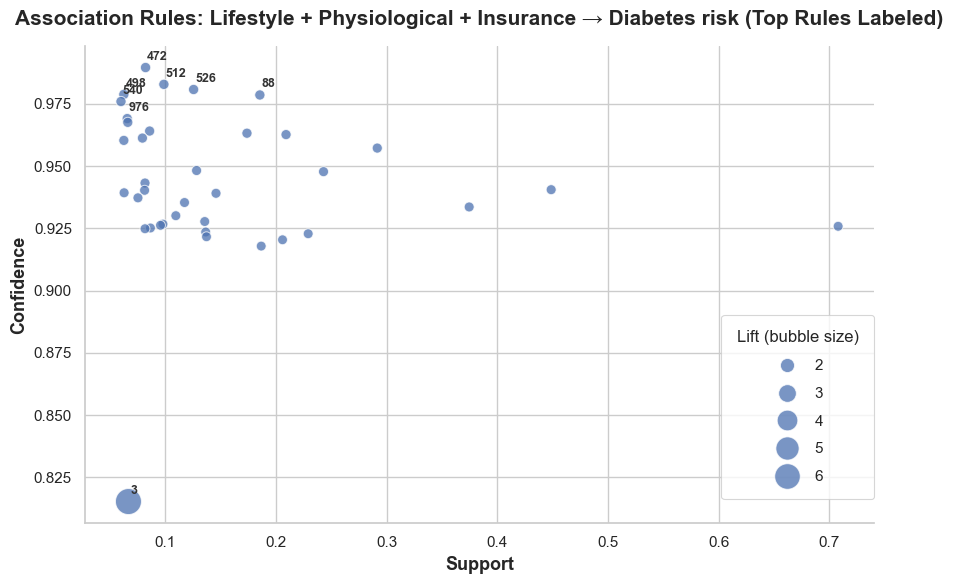

,antecedents,consequents,support,confidence,lift,kulc,ir
3,(a1c_bin=HighA1C_DiabetesRange),(diabetes_self_report=Yes),0.066601,0.815315,6.195029,0.660687,0.340301
472,"(a1c_bin=Normal_A1C, insurance_type=Private only, bmi_bin=Normal)",(diabetes_self_report=No),0.082056,0.989645,1.186032,0.543992,0.899706
512,"(sleep_bin=Normal (6-8h), a1c_bin=Normal_A1C, bmi_bin=Normal)",(diabetes_self_report=No),0.098614,0.982885,1.177931,0.550534,0.877952
526,"(a1c_bin=Normal_A1C, smoking_current=No, bmi_bin=Normal)",(diabetes_self_report=No),0.125475,0.980825,1.175461,0.565600,0.844203
498,"(sleep_bin=Long (>8h), a1c_bin=Normal_A1C, bmi_bin=Normal)",(diabetes_self_report=No),0.062431,0.978846,1.173090,0.526833,0.922072
88,"(a1c_bin=Normal_A1C, bmi_bin=Normal)",(diabetes_self_report=No),0.185331,0.978627,1.172827,0.600367,0.769310
540,"(a1c_bin=Normal_A1C, bmi_bin=Normal, smoking_current=Yes)",(diabetes_self_report=No),0.059855,0.976000,1.169679,0.523867,0.924872
976,"(smoking_current=No, insurance_type=Private only, bmi_bin=Normal)",(diabetes_self_report=No),0.065497,0.969147,1.161466,0.523821,0.916716
188,"(a1c_bin=Normal_A1C, insurance_type=Uninsured)",(diabetes_self_report=No),0.065988,0.967626,1.159643,0.523354,0.915848
260,"(insurance_type=Private only, bmi_bin=Normal)",(diabetes_self_report=No),0.085735,0.964138,1.155463,0.533443,0.890028


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

rules_diabetes = (
    rules[
        (rules['support'] > 0.05) &                     
        (rules['confidence'] > 0.3) &                  
        (rules['lift'] > 1.1) &                        
        (rules['consequents'].apply(lambda s: len(s) == 1)) &
        (rules['consequents'].apply(
            lambda s: list(s)[0].startswith('diabetes_self_report=')
        ))
    ]
    .sort_values('lift', ascending=False)
)

top_rules = rules_diabetes.nlargest(8, 'lift')   

plt.figure(figsize=(9, 6))

ax = sns.scatterplot(
    data=rules_diabetes,
    x='support',
    y='confidence',
    color='#4C72B0',      
    size='lift',
    sizes=(50, 350),
    alpha=0.75,
    edgecolor='white',
    linewidth=0.7
)

for idx, row in top_rules.iterrows():
    ax.text(
        row['support'] + 0.0015,
        row['confidence'] + 0.003,
        str(idx),
        fontsize=9,
        weight='bold',
        color='#333333'
    )

ax.set_title(
    "Association Rules: Lifestyle + Physiological + Insurance → Diabetes risk (Top Rules Labeled)",
    fontsize=15,
    pad=15,
    fontweight='bold'
)
ax.set_xlabel("Support", fontsize=13, fontweight='bold')
ax.set_ylabel("Confidence", fontsize=13, fontweight='bold')

ax.tick_params(axis='both', labelsize=11)

legend = ax.legend(
    title="Lift (bubble size)",
    title_fontsize=12,
    fontsize=11,
    frameon=True,
    borderpad=1,
    labelspacing=0.9,
    loc='lower right',          
    bbox_to_anchor=(1.0, 0.05),
    borderaxespad=0.0
)

legend.get_frame().set_linewidth(0.8)
legend.get_frame().set_edgecolor('#CCCCCC')

sns.despine()
plt.tight_layout()
plt.show()

rules_diabetes[['antecedents','consequents','support','confidence','lift','kulc','ir']].head(10)

In [18]:
# Lifestyle + Physiological + Insurance → A1C level
# Numeric data discretization

# A1C discretization
nhanes_clean_adult['a1c_bin'] = pd.cut(
    nhanes_clean_adult['a1c'],        
    bins=[0, 5.7, 6.5, np.inf],
    labels=['Normal_A1C', 'Prediabetes_A1C', 'HighA1C_DiabetesRange']
)

# BMI discretization
nhanes_clean_adult['bmi_bin'] = pd.cut(
    nhanes_clean_adult['bmi'],       
    bins=[0, 25, 30, np.inf],
    labels=['Normal', 'Overweight', 'Obesity']
)

# Sleep (hours) discretization
nhanes_clean_adult['sleep_bin'] = pd.cut(
    nhanes_clean_adult['sleep_hours'],   
    bins=[0, 6, 8, np.inf],
    labels=['Short (<6h)', 'Normal (6-8h)', 'Long (>8h)']
)

# Select Multi-domain Determinants
determinant_features = [
    'age_bin',
    'gender',
    'race',
    'education',
    'income_poverty_ratio_bin',
    'insurance_type',
    'a1c_bin',
    'bmi_bin',
    'sleep_bin',
    'smoking_current',
    'diabetes_self_report'
]
nhanes_health_fp = nhanes_clean_adult[determinant_features].dropna().astype(str)

# Convert the dataframe to transaction format
transactions = (
    nhanes_health_fp
    .apply(
        lambda r: [
            f"{c}={r[c]}" 
            for c in nhanes_health_fp.columns 
            if pd.notna(r[c])
        ],
        axis=1
    )
    .tolist()
)


te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
nhanes_health_tf = pd.DataFrame(te_ary, columns = te.columns_)
nhanes_health_tf

# Run Apriori algorithm
freq_items = apriori(nhanes_health_tf, min_support = 0.05, use_colnames = True, max_len = 4)
freq_items.sort_values('support',ascending = False).head()
freq_items[freq_items['itemsets'].apply(lambda x: len(x) > 1)].sort_values('support', ascending=False).head(10)

,support,itemsets
47,0.707838,"(a1c_bin=Normal_A1C, diabetes_self_report=No)"
226,0.516988,"(smoking_current=No, diabetes_self_report=No)"
220,0.493193,"(race=Non-Hispanic White, diabetes_self_report=No)"
69,0.476880,"(smoking_current=No, a1c_bin=Normal_A1C)"
208,0.464614,"(gender=Female, diabetes_self_report=No)"
64,0.456274,"(race=Non-Hispanic White, a1c_bin=Normal_A1C)"
487,0.448547,"(smoking_current=No, a1c_bin=Normal_A1C, diabetes_self_report=No)"
224,0.439715,"(sleep_bin=Normal (6-8h), diabetes_self_report=No)"
482,0.427327,"(race=Non-Hispanic White, a1c_bin=Normal_A1C, diabetes_self_report=No)"
52,0.425978,"(gender=Female, a1c_bin=Normal_A1C)"


In [19]:
# Generate Association rule
rules = association_rules(freq_items, metric = 'lift', min_threshold = 1.0)

# KULC
rules['kulc'] = 0.5 * (
    rules['support'] / rules['antecedent support'] +
    rules['support'] / rules['consequent support']
)

# Imbalance Ratio (IR)
rules['ir'] = (
    (rules['antecedent support'] - rules['consequent support']).abs()
    / (rules['antecedent support'] + rules['consequent support'] - rules['support'])
)

# Filter diabete risk as the consequent
rules_diabetes = rules[
    rules['consequents'].astype(str).str.contains('a1c_bin')
].copy()
rules_diabetes = rules_diabetes.sort_values('lift', ascending=False)

pd.set_option('display.max_colwidth', None)
rules_diabetes[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift',
     'kulc', 'ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
4,(diabetes_self_report=Yes),(a1c_bin=HighA1C_DiabetesRange),0.066601,0.506058,6.195029,0.660687,0.340301
4939,"(race=Non-Hispanic White, age_bin=61-80)","(insurance_type=Both, a1c_bin=Normal_A1C)",0.073593,0.269663,2.629859,0.493683,0.564405
4718,"(age_bin=61-80, diabetes_self_report=No)","(insurance_type=Both, a1c_bin=Normal_A1C)",0.078499,0.261118,2.546524,0.513334,0.610125
4583,"(insurance_type=Both, bmi_bin=Overweight)","(age_bin=61-80, a1c_bin=Normal_A1C)",0.050166,0.660743,2.506765,0.425532,0.648580
4941,(insurance_type=Both),"(age_bin=61-80, race=Non-Hispanic White, a1c_bin=Normal_A1C)",0.073593,0.468019,2.503777,0.430860,0.109701
4716,"(insurance_type=Both, diabetes_self_report=No)","(age_bin=61-80, a1c_bin=Normal_A1C)",0.078499,0.659114,2.500586,0.478464,0.475000
7453,"(education=College graduate or above, insurance_type=Private only)","(a1c_bin=Normal_A1C, income_poverty_ratio_bin=>4)",0.098123,0.561010,2.496677,0.498846,0.165175
4173,"(education=College graduate or above, age_bin=31-45)","(a1c_bin=Normal_A1C, insurance_type=Private only)",0.063535,0.759531,2.494945,0.484117,0.680272
4585,"(bmi_bin=Overweight, age_bin=61-80)","(insurance_type=Both, a1c_bin=Normal_A1C)",0.050166,0.250000,2.438098,0.369617,0.387785
3719,(age_bin=18-30),"(a1c_bin=Normal_A1C, smoking_current=No, bmi_bin=Normal)",0.051269,0.305332,2.386745,0.353050,0.163490


In [20]:
# Filter rules meet the criteria: support > 0.03, confidence > 0.3 and lift > 1.1
rules_diabetes = rules[
    (rules['support'] > 0.03) &
    (rules['confidence'] > 0.3) &
    (rules['lift'] > 1.1) &
    (rules['consequents'].apply(lambda s: len(s) == 1)) &
    (rules['consequents'].apply(lambda s: list(s)[0].startswith('a1c_bin')))
].sort_values('lift', ascending=False)

rules_diabetes[
    ['antecedents','consequents','support','confidence','lift','kulc','ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
4,(diabetes_self_report=Yes),(a1c_bin=HighA1C_DiabetesRange),0.066601,0.506058,6.195029,0.660687,0.340301
3812,"(race=Non-Hispanic White, diabetes_self_report=No, age_bin=18-30)",(a1c_bin=Normal_A1C),0.076782,0.993651,1.299733,0.547042,0.898349
3913,"(race=Non-Hispanic White, smoking_current=No, age_bin=18-30)",(a1c_bin=Normal_A1C),0.060959,0.992016,1.297594,0.535876,0.919032
3722,"(bmi_bin=Overweight, diabetes_self_report=No, age_bin=18-30)",(a1c_bin=Normal_A1C),0.070036,0.991319,1.296683,0.541464,0.906861
381,"(race=Non-Hispanic White, age_bin=18-30)",(a1c_bin=Normal_A1C),0.078131,0.990669,1.295832,0.546433,0.895977
345,"(bmi_bin=Overweight, age_bin=18-30)",(a1c_bin=Normal_A1C),0.071262,0.989779,1.294668,0.541496,0.904953
3733,"(bmi_bin=Overweight, smoking_current=No, age_bin=18-30)",(a1c_bin=Normal_A1C),0.054949,0.988962,1.293600,0.530419,0.926579
3708,"(smoking_current=No, bmi_bin=Normal, age_bin=18-30)",(a1c_bin=Normal_A1C),0.051269,0.976636,1.277476,0.521849,0.929841
3787,"(insurance_type=Private only, diabetes_self_report=No, age_bin=18-30)",(a1c_bin=Normal_A1C),0.071139,0.976431,1.277209,0.534742,0.902673
3836,"(diabetes_self_report=No, sleep_bin=Normal (6-8h), age_bin=18-30)",(a1c_bin=Normal_A1C),0.075310,0.976153,1.276845,0.537330,0.896927


In [21]:
abnormal_a1c = [
    'a1c_bin=Prediabetes_A1C',
    'a1c_bin=HighA1C_DiabetesRange'
]

rules_abnormal_a1c = (
    rules[
        (rules['support'] > 0.03) &
        (rules['confidence'] > 0.2) &
        (rules['lift'] > 1) &
        (rules['consequents'].apply(lambda s: len(s) == 1)) &
        (rules['consequents'].apply(lambda s: list(s)[0] in abnormal_a1c))
    ]
    .sort_values('lift', ascending=False)
)

rules_abnormal_a1c[
    ['antecedents','consequents','support','confidence','lift','kulc','ir']
].head(20)

,antecedents,consequents,support,confidence,lift,kulc,ir
4,(diabetes_self_report=Yes),(a1c_bin=HighA1C_DiabetesRange),0.066601,0.506058,6.195029,0.660687,0.340301
36,(bmi_bin=Obesity),(a1c_bin=Prediabetes_A1C),0.077640,0.234271,1.523135,0.369528,0.435751
1128,"(gender=Female, age_bin=61-80)",(a1c_bin=Prediabetes_A1C),0.051760,0.232635,1.512499,0.284579,0.211640
34,(age_bin=61-80),(a1c_bin=Prediabetes_A1C),0.092481,0.227451,1.478794,0.414363,0.540236
1140,"(bmi_bin=Obesity, diabetes_self_report=No)",(a1c_bin=Prediabetes_A1C),0.056544,0.224988,1.462780,0.296306,0.279733
1124,"(age_bin=61-80, diabetes_self_report=No)",(a1c_bin=Prediabetes_A1C),0.065252,0.217054,1.411199,0.320648,0.377246
1134,"(race=Non-Hispanic White, age_bin=61-80)",(a1c_bin=Prediabetes_A1C),0.057280,0.209888,1.364604,0.291148,0.322377


In [22]:
#Option3 

# Lifestyle + Physiological + Insurance → Diabetes
# Numeric data discretization

# A1C discretization
nhanes_clean_adult['a1c_bin'] = pd.cut(
    nhanes_clean_adult['a1c'],        
    bins=[0, 5.7, 6.5, np.inf],
    labels=['Normal_A1C', 'Prediabetes_A1C', 'HighA1C_DiabetesRange']
)

# BMI discretization
nhanes_clean_adult['bmi_bin'] = pd.cut(
    nhanes_clean_adult['bmi'],       
    bins=[0, 25, 30, np.inf],
    labels=['Normal', 'Overweight', 'Obesity']
)

# Sleep (hours) discretization
nhanes_clean_adult['sleep_bin'] = pd.cut(
    nhanes_clean_adult['sleep_hours'],   
    bins=[0, 6, 8, np.inf],
    labels=['Short (<6h)', 'Normal (6-8h)', 'Long (>8h)']
)

# Select Multi-domain Determinants
determinant_features = [
    'age_bin',
    'gender',
    'race',
    'education',
    'income_poverty_ratio_bin',
    'insurance_type',
    'bmi_bin',
    'sleep_bin',
    'smoking_current',
    'diabetes_self_report'
]
nhanes_health_fp = nhanes_clean_adult[determinant_features].dropna().astype(str)

# Convert the dataframe to transaction format
transactions = (
    nhanes_health_fp
    .apply(
        lambda r: [
            f"{c}={r[c]}" 
            for c in nhanes_health_fp.columns 
            if pd.notna(r[c])
        ],
        axis=1
    )
    .tolist()
)


te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
nhanes_health_tf = pd.DataFrame(te_ary, columns = te.columns_)
nhanes_health_tf

# Run Apriori algorithm
freq_items = apriori(nhanes_health_tf, min_support = 0.05, use_colnames = True, max_len = 4)
freq_items.sort_values('support',ascending = False).head()
freq_items[freq_items['itemsets'].apply(lambda x: len(x) > 1)].sort_values('support', ascending=False).head(10)

,support,itemsets
177,0.516988,"(smoking_current=No, diabetes_self_report=No)"
171,0.493193,"(race=Non-Hispanic White, diabetes_self_report=No)"
159,0.464614,"(gender=Female, diabetes_self_report=No)"
175,0.439715,"(sleep_bin=Normal (6-8h), diabetes_self_report=No)"
134,0.376916,"(bmi_bin=Overweight, diabetes_self_report=No)"
160,0.369803,"(diabetes_self_report=No, gender=Male)"
237,0.360849,"(gender=Female, smoking_current=No)"
162,0.338526,"(diabetes_self_report=No, income_poverty_ratio_bin=2-4)"
166,0.324666,"(insurance_type=Private only, diabetes_self_report=No)"
307,0.324666,"(race=Non-Hispanic White, smoking_current=No)"


In [23]:
# Generate Association rule
rules = association_rules(freq_items, metric = 'lift', min_threshold = 1.0)

# KULC
rules['kulc'] = 0.5 * (
    rules['support'] / rules['antecedent support'] +
    rules['support'] / rules['consequent support']
)

# Imbalance Ratio (IR)
rules['ir'] = (
    (rules['antecedent support'] - rules['consequent support']).abs()
    / (rules['antecedent support'] + rules['consequent support'] - rules['support'])
)

# Filter diabete risk as the consequent
rules_diabetes = rules[
    rules['consequents'].astype(str).str.contains('diabetes')
].copy()
rules_diabetes = rules_diabetes.sort_values('lift', ascending=False)

pd.set_option('display.max_colwidth', None)
rules_diabetes[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift',
     'kulc', 'ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
3854,"(race=Non-Hispanic White, age_bin=61-80)","(insurance_type=Both, diabetes_self_report=No)",0.086471,0.316854,2.660464,0.521455,0.503412
3107,"(income_poverty_ratio_bin=>4, age_bin=31-45)","(insurance_type=Private only, diabetes_self_report=No)",0.050534,0.835700,2.574031,0.495674,0.789589
3857,(insurance_type=Both),"(race=Non-Hispanic White, age_bin=61-80, diabetes_self_report=No)",0.086471,0.549922,2.563473,0.476505,0.200774
3263,(insurance_type=Private only),"(income_poverty_ratio_bin=>4, diabetes_self_report=No, age_bin=46-60)",0.052496,0.146575,2.443822,0.510915,0.815498
3110,(insurance_type=Private only),"(income_poverty_ratio_bin=>4, age_bin=31-45, diabetes_self_report=No)",0.050534,0.141096,2.442367,0.507915,0.822088
3008,"(education=College graduate or above, age_bin=31-45)","(insurance_type=Private only, diabetes_self_report=No)",0.066233,0.791789,2.438781,0.497897,0.704554
6033,"(education=College graduate or above, insurance_type=Private only)","(income_poverty_ratio_bin=>4, diabetes_self_report=No)",0.102294,0.584853,2.386539,0.501135,0.220849
3258,"(income_poverty_ratio_bin=>4, age_bin=46-60)","(insurance_type=Private only, diabetes_self_report=No)",0.052496,0.769784,2.371005,0.465738,0.753514
3851,"(insurance_type=Both, race=Non-Hispanic White)","(age_bin=61-80, diabetes_self_report=No)",0.086471,0.709970,2.361642,0.498804,0.532311
3705,"(gender=Female, age_bin=61-80)","(insurance_type=Both, diabetes_self_report=No)",0.061204,0.275083,2.309731,0.394493,0.368766


In [24]:
# Filter rules meet the criteria: support > 0.03, confidence > 0.3 and lift > 1.1
rules_diabetes = rules[
    (rules['support'] > 0.03) &
    (rules['confidence'] > 0.3) &
    (rules['lift'] > 1.1) &
    (rules['consequents'].apply(lambda s: len(s) == 1)) &
    (rules['consequents'].apply(lambda s: list(s)[0].startswith('diabetes')))
].sort_values('lift', ascending=False)

rules_diabetes[
    ['antecedents','consequents','support','confidence','lift','kulc','ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
2833,"(smoking_current=No, bmi_bin=Normal, age_bin=18-30)",(diabetes_self_report=No),0.051883,0.988318,1.184441,0.525248,0.936398
331,"(insurance_type=Private only, age_bin=18-30)",(diabetes_self_report=No),0.072857,0.985075,1.180555,0.536195,0.910159
295,"(bmi_bin=Normal, age_bin=18-30)",(diabetes_self_report=No),0.058629,0.983539,1.178714,0.526901,0.927470
2897,"(smoking_current=No, insurance_type=Private only, age_bin=18-30)",(diabetes_self_report=No),0.063412,0.982890,1.177936,0.529443,0.921462
4586,"(race=Non-Hispanic White, insurance_type=Private only, bmi_bin=Normal)",(diabetes_self_report=No),0.055930,0.982759,1.177779,0.524894,0.930700
349,"(sleep_bin=Normal (6-8h), age_bin=18-30)",(diabetes_self_report=No),0.077150,0.981279,1.176006,0.536869,0.904182
307,"(bmi_bin=Overweight, age_bin=18-30)",(diabetes_self_report=No),0.070649,0.981261,1.175984,0.532965,0.912240
2873,"(age_bin=18-30, smoking_current=No, gender=Male)",(diabetes_self_report=No),0.057770,0.981250,1.175971,0.525242,0.928215
2935,"(smoking_current=No, sleep_bin=Normal (6-8h), age_bin=18-30)",(diabetes_self_report=No),0.063044,0.980916,1.175571,0.528235,0.921620
2847,"(bmi_bin=Overweight, smoking_current=No, age_bin=18-30)",(diabetes_self_report=No),0.054458,0.980132,1.174632,0.522699,0.932179


In [25]:
diabetes = [
    'diabetes_self_report=Yes',
]

rules_diabetes = (
    rules[
        (rules['support'] > 0.03) &
        (rules['confidence'] > 0.1) &
        (rules['lift'] > 1.2) &
        (rules['consequents'].apply(lambda s: len(s) == 1)) &
        (rules['consequents'].apply(lambda s: list(s)[0] in diabetes))
    ]
    .sort_values('lift', ascending=False)
)

rules_diabetes[
    ['antecedents','consequents','support','confidence','lift','kulc','ir']
].head(20)

,antecedents,consequents,support,confidence,lift,kulc,ir
48,(age_bin=61-80),(diabetes_self_report=Yes),0.085245,0.209653,1.593012,0.428685,0.607095
90,(bmi_bin=Obesity),(diabetes_self_report=Yes),0.065129,0.196521,1.493231,0.345698,0.502158
150,(insurance_type=Public only),(diabetes_self_report=Yes),0.070036,0.182896,1.389700,0.357524,0.565397
153,(smoking_current=Yes),(diabetes_self_report=Yes),0.066356,0.166821,1.267559,0.335507,0.574834


In [26]:
# # Hypertension Exploration
def hypertension_stage(row):
    sbp = row['sbp']
    dbp = row['dbp']

    # Normal（incl. Elevated）
    if sbp < 130 and dbp < 80:
        return "Normal"

    # Stage 1 Hypertension
    elif (130 <= sbp < 140) or (80 <= dbp < 90):
        return "Stage 1"

    # Stage 2 Hypertension
    elif sbp >= 140 or dbp >= 90:
        return "Stage 2"

    else:
        return "Undefined"
        
nhanes_clean_adult['htn_stage'] = nhanes_clean_adult.apply(hypertension_stage, axis=1)

# Select Multi-domain Determinants
determinant_features = [
    'age_bin',
    'gender',
    'race',
    'education',
    'income_poverty_ratio_bin',
    'insurance_type',
    'bmi_bin',
    'sleep_bin',
    'smoking_current',
    'htn_stage'
]
nhanes_health_fp = nhanes_clean_adult[determinant_features].dropna().astype(str)

# Convert the dataframe to transaction format
transactions = (
    nhanes_health_fp
    .apply(
        lambda r: [
            f"{c}={r[c]}" 
            for c in nhanes_health_fp.columns 
            if pd.notna(r[c])
        ],
        axis=1
    )
    .tolist()
)


te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
nhanes_health_tf = pd.DataFrame(te_ary, columns = te.columns_)
nhanes_health_tf

# Run Apriori algorithm
freq_items = apriori(nhanes_health_tf, min_support = 0.05, use_colnames = True, max_len = 4)
freq_items.sort_values('support',ascending = False).head()
freq_items[freq_items['itemsets'].apply(lambda x: len(x) > 1)].sort_values('support', ascending=False).head(10)


,support,itemsets
250,0.418987,"(smoking_current=No, htn_stage=Normal)"
245,0.386851,"(race=Non-Hispanic White, htn_stage=Normal)"
201,0.384644,"(gender=Female, htn_stage=Normal)"
217,0.360849,"(gender=Female, smoking_current=No)"
248,0.352508,"(htn_stage=Normal, sleep_bin=Normal (6-8h))"
142,0.342083,"(bmi_bin=Overweight, htn_stage=Normal)"
317,0.324666,"(race=Non-Hispanic White, smoking_current=No)"
212,0.320005,"(gender=Female, race=Non-Hispanic White)"
322,0.318901,"(smoking_current=No, sleep_bin=Normal (6-8h))"
315,0.313995,"(race=Non-Hispanic White, sleep_bin=Normal (6-8h))"


In [27]:
# Generate Association rule
rules = association_rules(freq_items, metric = 'lift', min_threshold = 1.0)

# KULC
rules['kulc'] = 0.5 * (
    rules['support'] / rules['antecedent support'] +
    rules['support'] / rules['consequent support']
)

# Imbalance Ratio (IR)
rules['ir'] = (
    (rules['antecedent support'] - rules['consequent support']).abs()
    / (rules['antecedent support'] + rules['consequent support'] - rules['support'])
)

# Filter diabete risk as the consequent
rules_htn = rules[
    rules['consequents'].astype(str).str.contains('htn_stage')
].copy()
rules_htn = rules_htn.sort_values('lift', ascending=False)

pd.set_option('display.max_colwidth', None)
rules_htn[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift',
     'kulc', 'ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
3742,"(race=Non-Hispanic White, age_bin=61-80)","(insurance_type=Both, htn_stage=Normal)",0.063903,0.234157,2.555669,0.465807,0.603019
2967,"(education=College graduate or above, age_bin=31-45)","(insurance_type=Private only, htn_stage=Normal)",0.053477,0.639296,2.493867,0.423954,0.602740
3745,(insurance_type=Both),"(race=Non-Hispanic White, age_bin=61-80, htn_stage=Normal)",0.063903,0.406396,2.493114,0.399210,0.022488
5580,"(education=College graduate or above, insurance_type=Private only)","(income_poverty_ratio_bin=>4, htn_stage=Normal)",0.079357,0.453717,2.451393,0.441239,0.036276
2969,(insurance_type=Private only),"(age_bin=31-45, education=College graduate or above, htn_stage=Normal)",0.053477,0.149315,2.318792,0.489896,0.795945
3747,(age_bin=61-80),"(insurance_type=Both, race=Non-Hispanic White, htn_stage=Normal)",0.063903,0.157164,2.209244,0.527720,0.810611
5584,(income_poverty_ratio_bin=>4),"(insurance_type=Private only, education=College graduate or above, htn_stage=Normal)",0.079357,0.283772,2.188829,0.447941,0.454647
3739,"(insurance_type=Both, race=Non-Hispanic White)","(age_bin=61-80, htn_stage=Normal)",0.063903,0.524673,2.186941,0.395516,0.396623
5622,(education=College graduate or above),"(smoking_current=No, htn_stage=Normal, income_poverty_ratio_bin=>4)",0.089415,0.277714,2.164632,0.487328,0.536710
4240,"(bmi_bin=Overweight, education=College graduate or above)","(income_poverty_ratio_bin=>4, htn_stage=Normal)",0.056421,0.398268,2.151811,0.351553,0.160617


In [28]:
# Filter rules meet the criteria: support > 0.03, confidence > 0.2 and lift > 1.3
rules_htn = rules[
    (rules['support'] > 0.03) &
    (rules['confidence'] > 0.2) &
    (rules['lift'] > 1.3) &
    (rules['consequents'].apply(lambda s: len(s) == 1)) &
    (rules['consequents'].apply(lambda s: list(s)[0].startswith('htn_stage')))
].sort_values('lift', ascending=False)

rules_htn[
    ['antecedents','consequents','support','confidence','lift','kulc','ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
1402,"(race=Non-Hispanic White, bmi_bin=Obesity)",(htn_stage=Stage 1),0.063535,0.329098,1.463794,0.305847,0.089650
1412,"(smoking_current=No, bmi_bin=Obesity)",(htn_stage=Stage 1),0.062799,0.324051,1.441345,0.301687,0.087211
100,(bmi_bin=Obesity),(htn_stage=Stage 1),0.107200,0.323464,1.438736,0.400139,0.237367
1408,"(sleep_bin=Normal (6-8h), bmi_bin=Obesity)",(htn_stage=Stage 1),0.053845,0.318347,1.415974,0.278922,0.163722
2867,"(bmi_bin=Overweight, smoking_current=No, age_bin=18-30)",(htn_stage=Normal),0.052251,0.940397,1.386950,0.508730,0.913591
323,"(bmi_bin=Overweight, age_bin=18-30)",(htn_stage=Normal),0.067705,0.940375,1.386917,0.520115,0.888190
312,"(bmi_bin=Normal, age_bin=18-30)",(htn_stage=Normal),0.054336,0.911523,1.344364,0.495830,0.905044
333,"(gender=Female, age_bin=18-30)",(htn_stage=Normal),0.082056,0.910204,1.342419,0.515612,0.856811
2879,"(gender=Female, smoking_current=No, age_bin=18-30)",(htn_stage=Normal),0.071630,0.908243,1.339526,0.506943,0.874351
2931,"(gender=Female, bmi_bin=Overweight, age_bin=31-45)",(htn_stage=Normal),0.050902,0.908096,1.339311,0.491584,0.910413


In [29]:
htn = [
    'htn_stage=Stage 1',
    'htn_stage=Stage 2'
]

rules_htn = (
    rules[
        (rules['support'] > 0.03) &
        (rules['confidence'] > 0.1) &
        (rules['lift'] > 1.1) &
        (rules['consequents'].apply(lambda s: len(s) == 1)) &
        (rules['consequents'].apply(lambda s: list(s)[0] in htn))
    ]
    .sort_values('lift', ascending=False)
)

rules_htn[
    ['antecedents','consequents','support','confidence','lift','kulc','ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
59,(age_bin=61-80),(htn_stage=Stage 2),0.059242,0.145701,1.499878,0.377775,0.696192
1402,"(race=Non-Hispanic White, bmi_bin=Obesity)",(htn_stage=Stage 1),0.063535,0.329098,1.463794,0.305847,0.089650
1412,"(smoking_current=No, bmi_bin=Obesity)",(htn_stage=Stage 1),0.062799,0.324051,1.441345,0.301687,0.087211
100,(bmi_bin=Obesity),(htn_stage=Stage 1),0.107200,0.323464,1.438736,0.400139,0.237367
1408,"(sleep_bin=Normal (6-8h), bmi_bin=Obesity)",(htn_stage=Stage 1),0.053845,0.318347,1.415974,0.278922,0.163722
1336,"(gender=Female, bmi_bin=Obesity)",(htn_stage=Stage 1),0.059119,0.291239,1.295400,0.277098,0.059215
38,(age_bin=46-60),(htn_stage=Stage 1),0.057770,0.271470,1.207470,0.264213,0.031644
984,"(age_bin=61-80, smoking_current=No)",(htn_stage=Stage 1),0.056789,0.268873,1.195922,0.260732,0.035899
974,"(race=Non-Hispanic White, age_bin=61-80)",(htn_stage=Stage 1),0.073347,0.268764,1.195435,0.297503,0.113295
2662,"(race=Non-Hispanic White, income_poverty_ratio_bin=>4)",(htn_stage=Stage 1),0.055562,0.268206,1.192954,0.257671,0.046921
